## Introducción

La serie analizada corresponde al crecimiento de la población de Argentina entre los años 1961 y 2025.
Cada observación de la serie representa el crecimiento porcentual de la población del país con respecto
al año anterior.

La reducción de la natalidad en nuestro país es un tema frecuentamente reportado por los medios digitales y es 
interesante evaluar si esto coincide con los datos del aumento de la población.

La fuente de los datos, es la página de indicadores del Banco Mundial: https://datos.bancomundial.org/indicador/SP.POP.GROW?locations=AR

In [3]:
import matplotlib.pyplot as plt
from io import StringIO
import pandas as pd
import numpy as np
import statsmodels.api as sm

In [4]:
datos = StringIO(""""Country Name","Country Code","Indicator Name","Indicator Code","1960","1961","1962","1963","1964","1965","1966","1967","1968","1969","1970","1971","1972","1973","1974","1975","1976","1977","1978","1979","1980","1981","1982","1983","1984","1985","1986","1987","1988","1989","1990","1991","1992","1993","1994","1995","1996","1997","1998","1999","2000","2001","2002","2003","2004","2005","2006","2007","2008","2009","2010","2011","2012","2013","2014","2015","2016","2017","2018","2019","2020","2021","2022","2023","2024","2025"\n
"Argentina","ARG","Crecimiento de la población (%) anual","SP.POP.GROW","","1.65516691395024","1.65684089054911","1.64339841718671","1.61030882522813","1.56411446631364","1.53151134539948","1.52552564515699","1.5300700621594","1.53510695155484","1.56001941277121","1.57425828869798","1.58329622607322","1.61675611830692","1.64473215761616","1.60810835620248","1.56523230766791","1.58361041281169","1.59885003313826","1.59684779867466","1.59304228632554","1.60201232076144","1.60420679867482","1.6019042448548","1.59235691940308","1.57262930146869","1.55539122422629","1.54512926233209","1.54990330404865","1.53134817062707","1.49157462934909","1.43788006980649","1.38438120034139","1.35364018555542","1.3401375748685","1.3103115077878","1.25745217924583","1.21464795933597","1.17552563201514","1.15304317167294","1.13312807570195","1.09794672757946","1.06941318335345","1.0331399769648","1.01407652046238","1.02745772191722","1.02824760534561","0.991101935066697","1.01288878477428","1.05977470732485","1.05636332156278","1.06474009749784","1.0276613644946","0.992958989681133","1.0317435786984","1.04725888735726","0.968911125580978","0.881249595012674","0.822969480473088","0.710900853077743","0.484665636741261","0.265879395046274","0.210808731072658","0.286976121920089","0.345829819817895","0.339100654860035"
""")
series = pd.read_csv(datos)
series = series.drop(columns=["Country Name", "Indicator Name", "Indicator Code"])
series = pd.melt(series, id_vars=['Country Code'], var_name='año', value_name='crecimiento_anual')
series["año"] = series["año"].astype(int)
series = series[series["crecimiento_anual"].notna()]

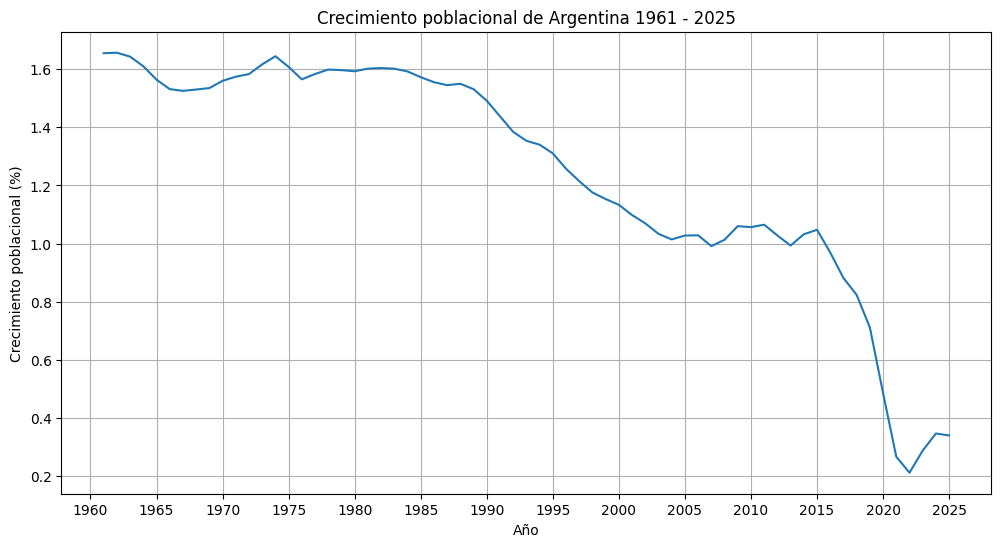

In [5]:
plt.figure(figsize=(12, 6))

plt.plot(series["año"], series["crecimiento_anual"])
plt.title(f"Crecimiento poblacional de Argentina {min(series['año'])} - {max(series['año'])}")
plt.xlabel("Año")
plt.ylabel("Crecimiento poblacional (%)")
plt.xticks([i for i in range(min(series["año"])-1, max(series["año"]) + 1, 5)])
plt.grid()

El gráfico muestra cómo el número de habitantes creció a ritmo más o menos constante desde 1961 hasta 1985, y luego comenzó
a caer hasta 2005. Desde 2025 hasta 2015 el crecimiento se mantuvo aproximadamente constante hasta el año 2015, en el que comienza una caída abrupta alcanzando un mínimo en el año 2022, coincidente con la pandemia de COVID.

La última observación indica que la población argentina creció un 0.33% entre 2024 y 2025.

## Métodos

### Media y Varianza
Se realizó un suavizado con media móvil simple y exponencial utilizando una ventana de tamaño 3. La curva exponencial se acerca más a la original en los períodos de cambio abrupto ya que los años más alejados tienen menor influencia en la media
móvil.

La media móvil permite ver que la serie no tiene media constante en el tiempo. Se incluye la desviación estándar movil para evaluar visualmente el comportamient de la varianza, que no es constante en el tiempo y tiene un pico máximo en 2021. 
Se usa el desvío es porque tiene las mismas unidades de la serie original. 

Debido a que la media y la varianza móviles varían en el tiempo se concluye que la serie no es estacionaria.

In [6]:
series["sma_3"] = series["crecimiento_anual"].rolling(window=3, center=False).mean()
series["std_3"] = series["crecimiento_anual"].rolling(window=3, center=False).std()
series["ewma_3"] = series["crecimiento_anual"].ewm(span=3, adjust=True).mean()

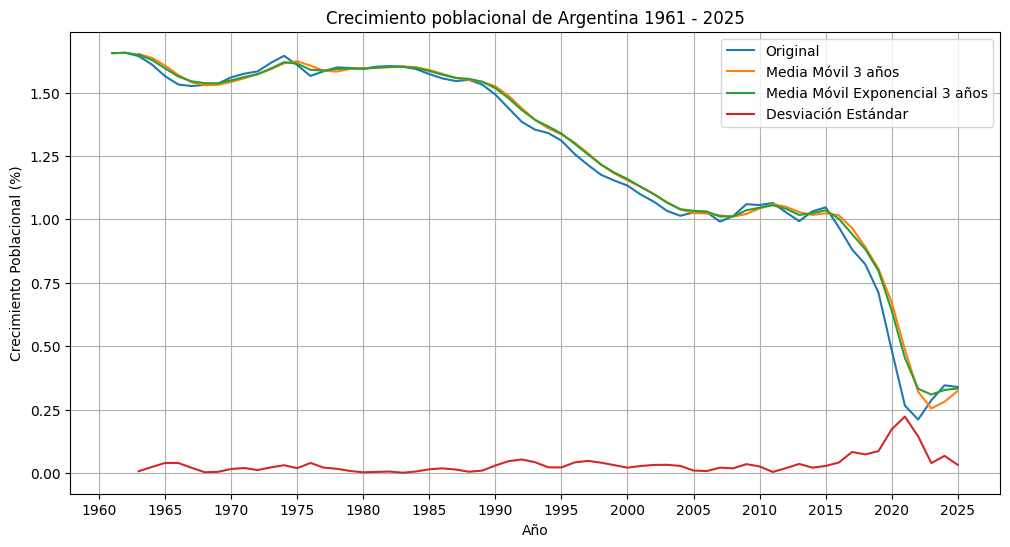

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(series["año"], series["crecimiento_anual"])
plt.plot(series["año"], series["sma_3"])

plt.plot(series["año"], series["ewma_3"])
plt.plot(series["año"], series["std_3"])

plt.legend(["Original", 
            "Media Móvil 3 años",  
            "Media Móvil Exponencial 3 años",
            "Desviación Estándar"
            ])
plt.title(f"Crecimiento poblacional de Argentina {min(series['año'])} - {max(series['año'])}")
plt.xlabel("Año")
plt.ylabel("Crecimiento Poblacional (%)")
plt.xticks([i for i in range(min(series["año"])-1, max(series["año"]) + 1, 5)])
plt.grid()

### Tendencia

Dado que la serie tiene errores multiplicativos, se transforma a escala logarítmica usando el logaritmo en base 10.

#### Ajuste 
Se ajustan polinomios de grados 0 a 10 y se evalua el coeficiente de determinación para decidir en función de un balance entre ajuste y parsimonia. 

In [8]:
series["crecimiento_anual_log"] = np.log10(series["crecimiento_anual"])

ajustes = []
# plt.plot(series["año"], series["crecimiento_anual_log"], label="Crecimiento poblacional (log10)")
for degree in range(0, 11):
    coefficients = np.polyfit(series["año"], series["crecimiento_anual_log"], deg=degree)
    series[f"trend_poly_{degree}_log"] = np.polyval(coefficients, series["año"])
    # plt.plot(series["año"], trend, label=f"Tendencia Polinómica Grado {degree}")

    residuals = series["crecimiento_anual_log"] - series[f"trend_poly_{degree}_log"]
    rss = np.sum(residuals**2)
    tss = np.sum((series["crecimiento_anual_log"] - np.mean(series["crecimiento_anual_log"])) ** 2)
    r2 = 1 - (rss / tss)
    # print(f"R^2({degree}): {r2}")
    ajustes.append((degree, r2))
# plt.legend()

df_ajustes = pd.DataFrame(ajustes, columns=["Grado del Polinomio", "R^2"])
df_ajustes

/tmp/ipykernel_6435/3681618376.py:6: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(series["año"], series["crecimiento_anual_log"], deg=degree)
/tmp/ipykernel_6435/3681618376.py:6: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(series["año"], series["crecimiento_anual_log"], deg=degree)
/tmp/ipykernel_6435/3681618376.py:6: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(series["año"], series["crecimiento_anual_log"], deg=degree)
/tmp/ipykernel_6435/3681618376.py:6: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(series["año"], series["crecimiento_anual_log"], deg=degree)
/tmp/ipykernel_6435/3681618376.py:6: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(series["año"], series["crecimiento_anual_log"], deg=degree)


,Grado del Polinomio,R^2
0,0,0.000000
1,1,0.627244
2,2,0.823485
3,3,0.865721
4,4,0.890420
5,5,0.906659
6,6,0.906600
7,7,0.910083
8,8,0.910149
9,9,0.910225


Se grafican los ajustes hasta el polinomio de grado 5 inclusive. Si bien para grados mayores el coeficiente de determinación aumenta, se prefiere un ajuste más simple.

/tmp/ipykernel_6435/2860527477.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  r2 = float(df_ajustes[df_ajustes["Grado del Polinomio"]==degree]["R^2"])


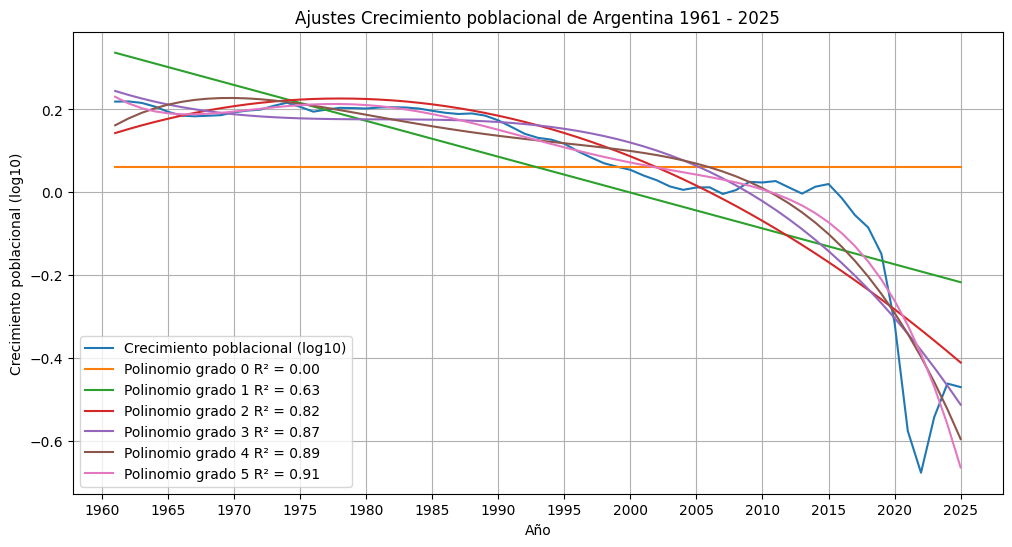

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(series["año"], series["crecimiento_anual_log"], label="Crecimiento poblacional (log10)")
for degree in range(0, 6):
    r2 = float(df_ajustes[df_ajustes["Grado del Polinomio"]==degree]["R^2"])
    plt.plot(series["año"], series[f"trend_poly_{degree}_log"], label=f"Polinomio grado {degree} R² = {r2:.2f}")
plt.title(f"Ajustes Crecimiento poblacional de Argentina {min(series['año'])} - {max(series['año'])}")
plt.xlabel("Año")
plt.ylabel("Crecimiento poblacional (log10)")
plt.xticks([i for i in range(min(series["año"])-1, max(series["año"]) + 1, 5)])
plt.grid()
plt.legend()
plt.show()

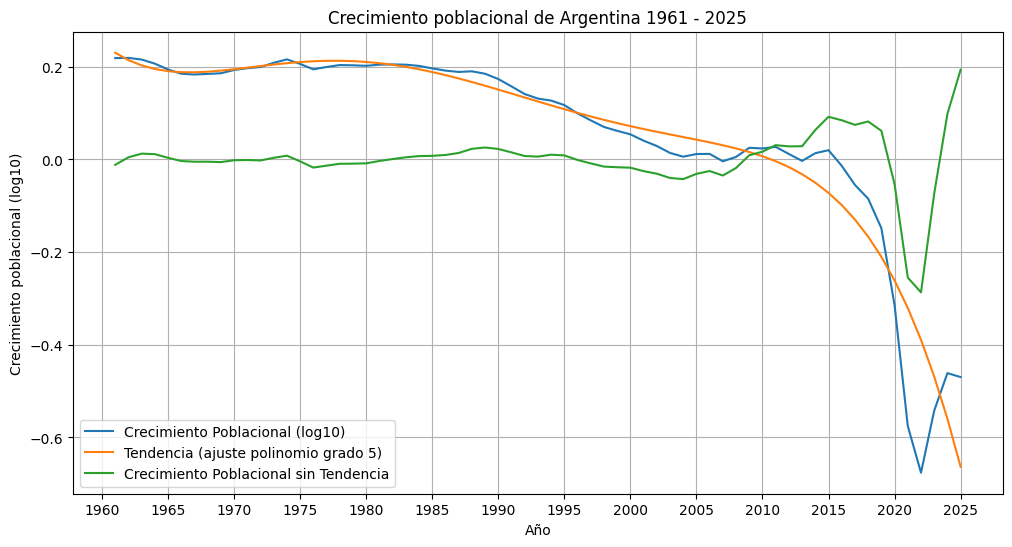

In [12]:
plt.figure(figsize=(12, 6))
series["detrend_poly_5_log"] = series["crecimiento_anual_log"] - series["trend_poly_5_log"] 

plt.plot(series["año"], series["crecimiento_anual_log"], label="Crecimiento Poblacional (log10)")
plt.plot(series["año"], series["trend_poly_5_log"], label="Tendencia (ajuste polinomio grado 5)")

plt.plot(series["año"], series["detrend_poly_5_log"], label="Crecimiento Poblacional sin Tendencia")
plt.legend()
plt.title(f"Crecimiento poblacional de Argentina {min(series['año'])} - {max(series['año'])}")
plt.xlabel("Año")
plt.ylabel("Crecimiento poblacional (log10)")
plt.xticks([i for i in range(min(series["año"])-1, max(series["año"]) + 1, 5)])
plt.grid()
plt.show()

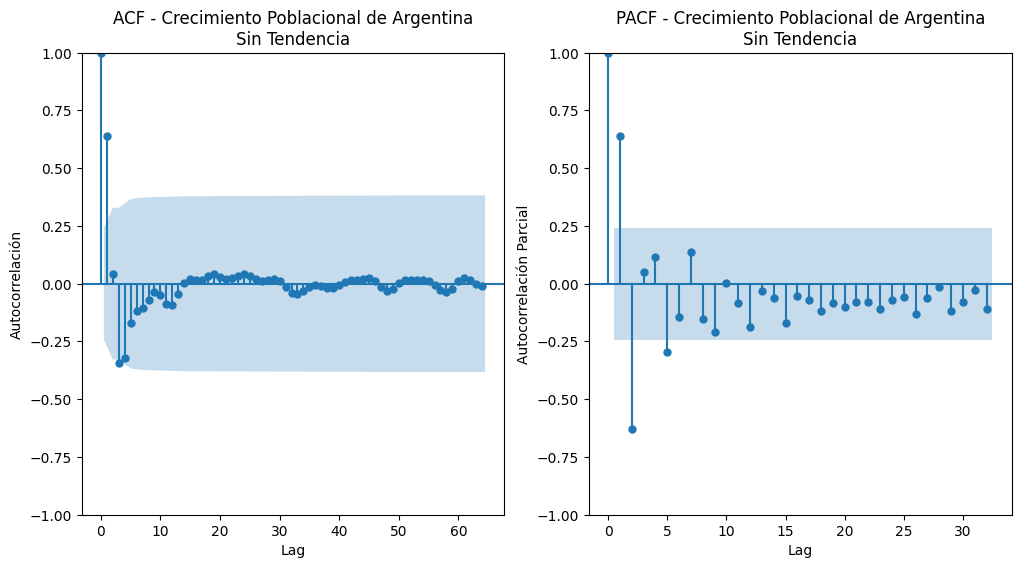

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sm.graphics.tsa.plot_acf(series["detrend_poly_5_log"], lags=len(series["detrend_poly_5_log"])-1, ax=axes[0])
sm.graphics.tsa.plot_pacf(series["detrend_poly_5_log"], lags=32, ax=axes[1])

axes[0].set_title("ACF - Crecimiento Poblacional de Argentina\nSin Tendencia")
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("Autocorrelación")
axes[1].set_title("PACF - Crecimiento Poblacional de Argentina\nSin Tendencia")
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("Autocorrelación Parcial")

plt.show()

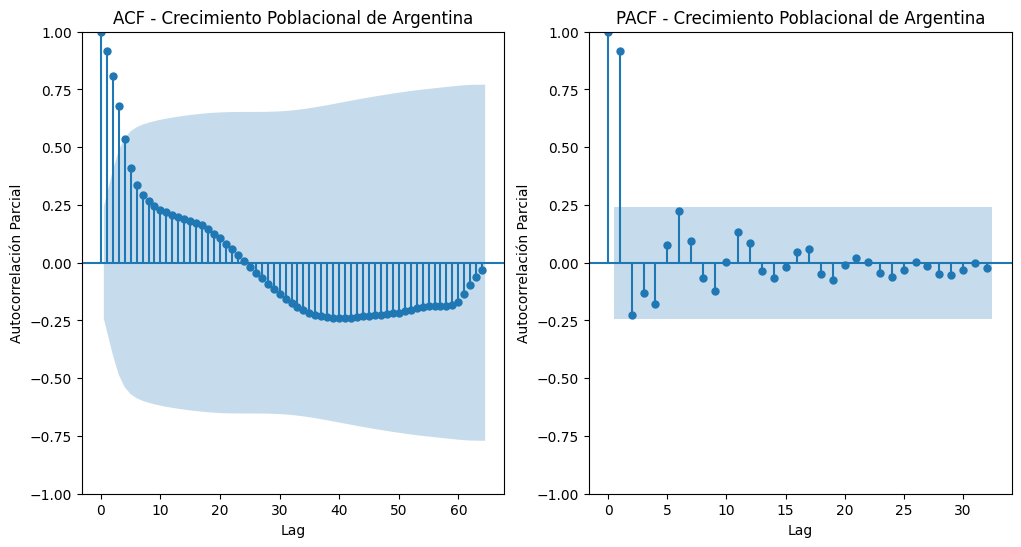

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sm.graphics.tsa.plot_acf(series["crecimiento_anual_log"], lags=len(series["crecimiento_anual_log"])-1, ax=axes[0])
sm.graphics.tsa.plot_pacf(series["crecimiento_anual_log"], lags=32, ax=axes[1])

axes[0].set_ylabel("Autocorrelación Parcial")
axes[0].set_title("ACF - Crecimiento Poblacional de Argentina")
axes[0].set_xlabel("Lag")
axes[1].set_ylabel("Autocorrelación Parcial")
axes[1].set_title("PACF - Crecimiento Poblacional de Argentina")
axes[1].set_xlabel("Lag")

plt.show()

La función de autocorrelación parcial indica que los lags 1, 2 y 5 son significativos. Para construir un modelo autoregresivo 
se podrian usar los dos años anteriores.